**生成式 AI 使用说明**：在本课程作业中，使用生成式 AI 需要遵守与协作讨论相同的政策。和其他合作者一样，每位学生都必须独立写出自己的解答，不能直接依赖交互输出完成提交内容，并且提交时应说明协作的性质。使用生成式 AI 工具实质性地完成作业中的部分内容，不符合本课程作业精神，也会违反 [Honor Code](https://communitystandards.stanford.edu/policies-and-guidance/honor-code)。

In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment1/'
FOLDERNAME = 'cs231n/assignments/assignment1/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
!bash get_datasets.sh
%cd /content/drive/My\ Drive/$FOLDERNAME

# k-Nearest Neighbor（kNN）练习

*请完成并提交这份 worksheet，包括运行输出，以及 worksheet 之外你修改过的所有辅助代码。更多细节请参考课程网站上的 [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html)。*

kNN 分类器分为两个阶段：

- 训练阶段：分类器接收训练数据，并且只是把它们“记住”。
- 测试阶段：kNN 会把每一张测试图片与所有训练图片进行比较，然后把最相似的 k 个训练样本的标签拿来投票。
- k 的取值需要通过交叉验证来选择。

在这个练习中，你会实现这些步骤，并理解图像分类的基本流程、交叉验证，同时练习编写高效的向量化代码。

In [1]:
# Run some setup code for this notebook.

import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

# This is a bit of magic to make matplotlib figures appear inline in the notebook
# rather than in a new window.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Some more magic so that the notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

In [2]:
# Load the raw CIFAR-10 data.
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


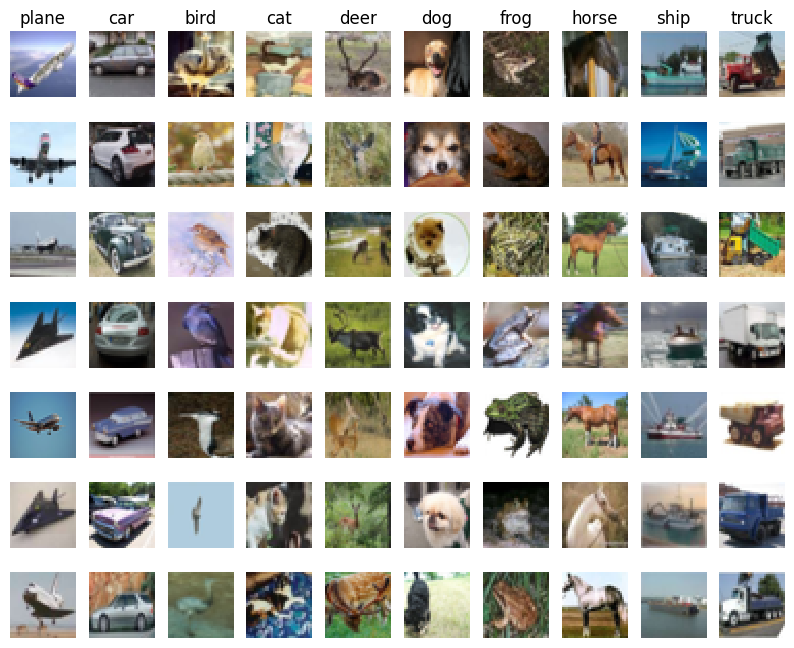

In [3]:
# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [4]:
# Subsample the data for more efficient code execution in this exercise
num_training = 5000
mask = list(range(num_training))
X_train = X_train[mask]
y_train = y_train[mask]

num_test = 500
mask = list(range(num_test))
X_test = X_test[mask]
y_test = y_test[mask]

# Reshape the image data into rows
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
print(X_train.shape, X_test.shape)

(5000, 3072) (500, 3072)


In [5]:
from cs231n.classifiers import KNearestNeighbor

# Create a kNN classifier instance.
# Remember that training a kNN classifier is a noop:
# the Classifier simply remembers the data and does no further processing
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

现在我们希望用 kNN 分类器对测试数据进行分类。回顾一下，这个过程可以拆成两步：

1. 首先，计算所有测试样本与所有训练样本之间的距离。
2. 得到这些距离后，对每个测试样本找出距离最近的 k 个训练样本，并让它们对标签进行投票。

先从计算训练样本和测试样本之间的距离矩阵开始。举例来说，如果有 **Ntr** 个训练样本和 **Nte** 个测试样本，那么这一步应该得到一个 **Nte x Ntr** 的矩阵，其中元素 `(i, j)` 表示第 `i` 个测试样本和第 `j` 个训练样本之间的距离。

**注意：本 notebook 要求你实现三种距离计算方式，在这些实现中不能使用 NumPy 提供的 `np.linalg.norm()` 函数。**

首先，打开 `cs231n/classifiers/k_nearest_neighbor.py`，实现 `compute_distances_two_loops` 函数。这个函数使用非常低效的双重循环，遍历所有 `(test, train)` 样本对，并逐个元素计算距离矩阵。

In [7]:
# Open cs231n/classifiers/k_nearest_neighbor.py and implement
# compute_distances_two_loops.

# Test your implementation:
dists = classifier.compute_distances_two_loops(X_test)
print(dists.shape)

(500, 5000)


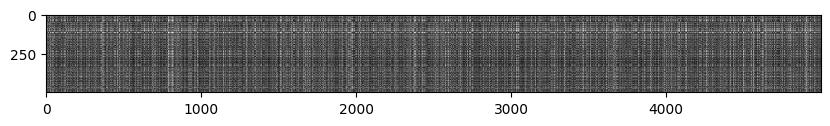

In [8]:
# We can visualize the distance matrix: each row is a single test example and
# its distances to training examples
plt.imshow(dists, interpolation='none')
plt.show()

**Inline Question 1**

观察距离矩阵中的结构化模式，有些行或列会明显更亮。（注意：在默认配色中，黑色表示距离小，白色表示距离大。）

- 数据中的什么因素会导致明显更亮的行？
- 什么因素会导致明显更亮的列？

$\color{blue}{	extit Your Answer:}$ *在这里填写你的答案。*

In [9]:
# Now implement the function predict_labels and run the code below:
# We use k = 1 (which is Nearest Neighbor).
y_test_pred = classifier.predict_labels(dists, k=1)

# Compute and print the fraction of correctly predicted examples
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 137 / 500 correct => accuracy: 0.274000


你应该会看到大约 `27%` 的准确率。现在试一个更大的 `k`，比如 `k = 5`：

In [10]:
y_test_pred = classifier.predict_labels(dists, k=5)
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 139 / 500 correct => accuracy: 0.278000


你应该会看到它比 `k = 1` 时的表现略好一些。

**Inline Question 2**

我们也可以使用其他距离度量，例如 L1 距离。
对于某张图像 $I_k$ 中位置 $(i,j)$ 的像素值 $p_{ij}^{(k)}$，

所有图像、所有像素上的整体均值 $\mu$ 定义为：
$$\mu=\frac{1}{nhw}\sum_{k=1}^n\sum_{i=1}^{h}\sum_{j=1}^{w}p_{ij}^{(k)}$$

所有图像在每个像素位置上的逐像素均值 $\mu_{ij}$ 定义为：
$$\mu_{ij}=\frac{1}{n}\sum_{k=1}^np_{ij}^{(k)}.$$

整体标准差 $\sigma$ 和逐像素标准差 $\sigma_{ij}$ 也可以用类似方式定义。

如果最近邻分类器使用 L1 距离，下面哪些预处理步骤不会改变它的分类表现？请选择所有适用项。为避免歧义，训练样本和测试样本都会用相同方式进行预处理。

1. 减去整体均值 $\mu$（$\tilde{p}_{ij}^{(k)}=p_{ij}^{(k)}-\mu$）。
2. 减去逐像素均值 $\mu_{ij}$（$\tilde{p}_{ij}^{(k)}=p_{ij}^{(k)}-\mu_{ij}$）。
3. 减去整体均值 $\mu$，再除以整体标准差 $\sigma$。
4. 减去逐像素均值 $\mu_{ij}$，再除以逐像素标准差 $\sigma_{ij}$。
5. 旋转数据的坐标轴，也就是把所有图像旋转相同角度。旋转产生的空白区域用相同像素值填充，并且不进行插值。

$\color{blue}{\textit{Your Answer:}}$


$\color{blue}{\textit{Your Explanation:}}$


In [10]:
# Now lets speed up distance matrix computation by using partial vectorization
# with one loop. Implement the function compute_distances_one_loop and run the
# code below:
dists_one = classifier.compute_distances_one_loop(X_test)

# To ensure that our vectorized implementation is correct, we make sure that it
# agrees with the naive implementation. There are many ways to decide whether
# two matrices are similar; one of the simplest is the Frobenius norm. In case
# you haven't seen it before, the Frobenius norm of two matrices is the square
# root of the squared sum of differences of all elements; in other words, reshape
# the matrices into vectors and compute the Euclidean distance between them.
difference = np.linalg.norm(dists - dists_one, ord='fro')
print('One loop difference was: %f' % (difference, ))
if difference < 0.001:
    print('Good! The distance matrices are the same')
else:
    print('Uh-oh! The distance matrices are different')

One loop difference was: 0.000000
Good! The distance matrices are the same


In [11]:
# Now implement the fully vectorized version inside compute_distances_no_loops
# and run the code
dists_two = classifier.compute_distances_no_loops(X_test)

# check that the distance matrix agrees with the one we computed before:
difference = np.linalg.norm(dists - dists_two, ord='fro')
print('No loop difference was: %f' % (difference, ))
if difference < 0.001:
    print('Good! The distance matrices are the same')
else:
    print('Uh-oh! The distance matrices are different')

No loop difference was: 0.000000
Good! The distance matrices are the same


In [12]:
# Let's compare how fast the implementations are
def time_function(f, *args):
    """
    Call a function f with args and return the time (in seconds) that it took to execute.
    """
    import time
    tic = time.time()
    f(*args)
    toc = time.time()
    return toc - tic

two_loop_time = time_function(classifier.compute_distances_two_loops, X_test)
print('Two loop version took %f seconds' % two_loop_time)

one_loop_time = time_function(classifier.compute_distances_one_loop, X_test)
print('One loop version took %f seconds' % one_loop_time)

no_loop_time = time_function(classifier.compute_distances_no_loops, X_test)
print('No loop version took %f seconds' % no_loop_time)

# You should see significantly faster performance with the fully vectorized implementation!

# NOTE: depending on what machine you're using,
# you might not see a speedup when you go from two loops to one loop,
# and might even see a slow-down.

Two loop version took 16.968017 seconds
One loop version took 40.125769 seconds
No loop version took 0.211001 seconds


### 交叉验证

我们已经实现了 k-Nearest Neighbor 分类器，但前面只是随意设定了 `k = 5`。现在我们会通过交叉验证来确定这个超参数的最佳取值。

In [12]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50, 100]

X_train_folds = []
y_train_folds = []
################################################################################
# TODO:                                                                        #
X_train_folds=np.array_split(X_train,num_folds)
y_train_folds=np.array_split(y_train,num_folds)
# Split up the training data into folds. After splitting, X_train_folds and    #
# y_train_folds should each be lists of length num_folds, where                #
# y_train_folds[i] is the label vector for the points in X_train_folds[i].     #
# Hint: Look up the numpy array_split function.                                #
################################################################################


# A dictionary holding the accuracies for different values of k that we find
# when running cross-validation. After running cross-validation,
# k_to_accuracies[k] should be a list of length num_folds giving the different
# accuracy values that we found when using that value of k.
k_to_accuracies = {}


################################################################################
# TODO:                                                                        #
for k in k_choices:
    k_to_accuracies[k]=[]

    for i in range(num_folds):
        X_val=X_train_folds[i]
        y_val=y_train_folds[i]

        X_train_cv=np.concatenate(
            X_train_folds[:i]+X_train_folds[i+1:],
            axis=0
        )
        y_train_cv=np.concatenate(
            y_train_folds[:i]+y_train_folds[i+1:],
            axis=0
        )

        classifier=KNearestNeighbor()
        classifier.train(X_train_cv,y_train_cv)
        y_pre=classifier.predict(X_val,k=k,num_loops=0)
        num_correct=np.sum(y_pre==y_val)
        accuracy=float(num_correct)/X_val.shape[0]
        k_to_accuracies[k].append(accuracy)

# Perform k-fold cross validation to find the best value of k. For each        #
# possible value of k, run the k-nearest-neighbor algorithm num_folds times,   #
# where in each case you use all but one of the folds as training data and the #
# last fold as a validation set. Store the accuracies for all fold and all     #
# values of k in the k_to_accuracies dictionary.                               #
################################################################################


# Print out the computed accuracies
for k in sorted(k_to_accuracies):
    for accuracy in k_to_accuracies[k]:
        print('k = %d, accuracy = %f' % (k, accuracy))

k = 1, accuracy = 0.263000
k = 1, accuracy = 0.257000
k = 1, accuracy = 0.264000
k = 1, accuracy = 0.278000
k = 1, accuracy = 0.266000
k = 3, accuracy = 0.239000
k = 3, accuracy = 0.249000
k = 3, accuracy = 0.240000
k = 3, accuracy = 0.266000
k = 3, accuracy = 0.254000
k = 5, accuracy = 0.248000
k = 5, accuracy = 0.266000
k = 5, accuracy = 0.280000
k = 5, accuracy = 0.292000
k = 5, accuracy = 0.280000
k = 8, accuracy = 0.262000
k = 8, accuracy = 0.282000
k = 8, accuracy = 0.273000
k = 8, accuracy = 0.290000
k = 8, accuracy = 0.273000
k = 10, accuracy = 0.265000
k = 10, accuracy = 0.296000
k = 10, accuracy = 0.276000
k = 10, accuracy = 0.284000
k = 10, accuracy = 0.280000
k = 12, accuracy = 0.260000
k = 12, accuracy = 0.295000
k = 12, accuracy = 0.279000
k = 12, accuracy = 0.283000
k = 12, accuracy = 0.280000
k = 15, accuracy = 0.252000
k = 15, accuracy = 0.289000
k = 15, accuracy = 0.278000
k = 15, accuracy = 0.282000
k = 15, accuracy = 0.274000
k = 20, accuracy = 0.270000
k = 20, accu

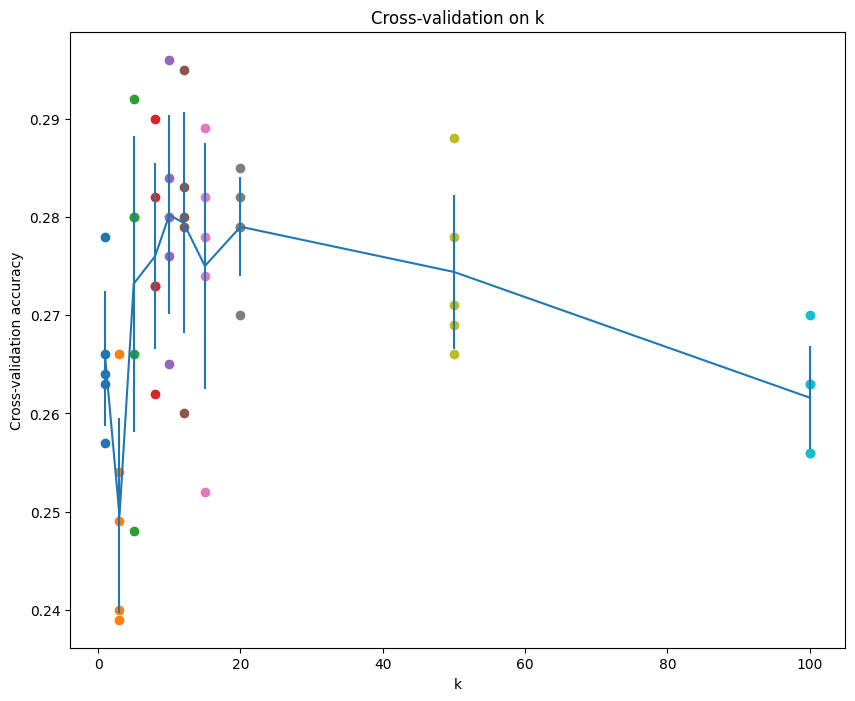

In [13]:
# plot the raw observations
for k in k_choices:
    accuracies = k_to_accuracies[k]
    plt.scatter([k] * len(accuracies), accuracies)

# plot the trend line with error bars that correspond to standard deviation
accuracies_mean = np.array([np.mean(v) for k,v in sorted(k_to_accuracies.items())])
accuracies_std = np.array([np.std(v) for k,v in sorted(k_to_accuracies.items())])
plt.errorbar(k_choices, accuracies_mean, yerr=accuracies_std)
plt.title('Cross-validation on k')
plt.xlabel('k')
plt.ylabel('Cross-validation accuracy')
plt.show()

In [37]:
# Based on the cross-validation results above, choose the best value for k,
# retrain the classifier using all the training data, and test it on the test
# data. You should be able to get above 28% accuracy on the test data.
best_k = 10

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k)

# Compute and display the accuracy
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 141 / 500 correct => accuracy: 0.282000


**Inline Question 3**

在分类任务中，关于 $k$-Nearest Neighbor（$k$-NN），下面哪些说法对所有 $k$ 都成立？请选择所有适用项。

1. k-NN 分类器的决策边界是线性的。
2. 1-NN 的训练误差总是小于或等于 5-NN 的训练误差。
3. 1-NN 的测试误差总是小于 5-NN 的测试误差。
4. 使用 k-NN 分类一个测试样本所需的时间会随着训练集规模增大而增长。
5. 以上都不对。

$\color{blue}{	extit Your Answer:}$


$\color{blue}{	extit Your Explanation:}$